<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/ANN_assinment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Artificial Neural Network (ANN) Assignment

Problem Statement

This assignment focuses on utilizing Artificial Neural Networks (ANN) to analyze provided datasets, extracting patterns and insights from the underlying structures. By exploring the datasets and employing ANN techniques, students are expected to build a predictive model for a specific task. This assignment emphasizes parameter tuning for optimal model performance and requires interpretation of the model outcomes to derive valuable insights.

Guidelines

1. Foundational Knowledge
   - Understand the basics of Artificial Neural Networks, including the architecture, activation functions, and training process.
   - Familiarize yourself with different types of neural networks and their applications.

2. Data Exploration
   - Analyze the dataset's structure and characteristics using various exploratory techniques such as histograms, scatter plots, correlation matrices, etc.
   - Identify relevant features for the predictive task and gain insights into their relationships.

3. Preprocessing and Feature Engineering
   - Handle missing data and outliers appropriately.
   - Standardize or normalize features if required.
   - Encode categorical variables using suitable techniques.

4. Neural Network Architecture
   - Decide on the type of neural network architecture suitable for the task.
   - Determine the number of layers and nodes in each layer based on the complexity of the task.

5. Model Training and Parameter Tuning
   - Split the dataset into training and testing sets.
   - Choose appropriate hyperparameters (e.g., learning rate, batch size, epochs) for model training.
   - Train the ANN model using the training dataset.
   - Monitor the training process and adjust hyperparameters if necessary.

6. Model Evaluation
   - Evaluate the model on the testing dataset using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
   - Explore the model's performance through confusion matrices and ROC curves if applicable.

7. Interpretation and Analysis
   - Interpret the model's outcomes and analyze feature importance.
   - Visualize the model's predictions and compare them with actual values.
   - Discuss any challenges encountered during the modeling process and potential improvements.

Step-by-Step Approach to ANN Modeling

1. Setup and Data Preparation
   - Import necessary libraries: pandas, matplotlib, scikit-learn, TensorFlow or PyTorch.
   - Load the dataset for modeling.
   - Preprocess the data, handling missing values, outliers, and encoding categorical variables.

2. Neural Network Architecture
   - Choose the appropriate type of neural network architecture for the task.
   - Define the number of layers and nodes in each layer.

3. Model Training and Parameter Tuning
   - Split the dataset into training and testing sets.
   - Choose hyperparameters for the model (learning rate, batch size, etc.).
   - Train the ANN model using the training dataset.
   - Monitor the training process and adjust hyperparameters if needed.

4. Model Evaluation
   - Evaluate the model on the testing dataset using relevant metrics.
   - Explore the model's performance through additional visualizations (confusion matrix, ROC curve).

5. Interpretation and Analysis
   - Interpret the model's predictions and analyze feature importance.
   - Visualize the model's outcomes and compare them with actual values.
   - Discuss insights gained from the model and potential areas for improvement.

Link to Datasets for the Assignment

- Lung Cancer Dataset
https://www.kaggle.com/datasets/nancyalaswad90/lung-cancer

- Heart Disease Prediction Dataset
https://www.kaggle.com/datasets/rishidamarla/heart-disease-prediction

- Digits Dataset
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html


In [1]:
## imprting the nessasary libraries
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)
print(digits.target.shape)

(1797, 64)
(1797,)


The `load_digits` dataset is a classic dataset in scikit-learn for classification tasks. It consists of images of handwritten digits from 0 to 9.

Here are the key details of the `digits` dataset:

*   **Number of Samples:** It contains 1797 samples, where each sample is an 8x8 grayscale image of a digit.
*   **Number of Features:** Each image is represented as a flattened array of 64 features (8 pixels * 8 pixels). The pixel values are integers ranging from 0 to 16, representing different shades of gray.
*   **Target (Labels):** The dataset includes 10 possible target classes (0 to 9), representing the digit shown in the image.
*   **Data Structure:**
    *   `digits.data`: A 2D array of shape `(1797, 64)`, where each row is a flattened digit image.
    *   `digits.images`: A 3D array of shape `(1797, 8, 8)`, containing the original 8x8 image data.
    *   `digits.target`: A 1D array of shape `(1797,)`, containing the true label (0-9) for each image.
*   **Purpose:** It's commonly used for demonstrating classification algorithms, particularly for tasks like optical character recognition (OCR) of handwritten digits.

In [3]:
##Getting an idea about data
digits.data.shape

(1797, 64)

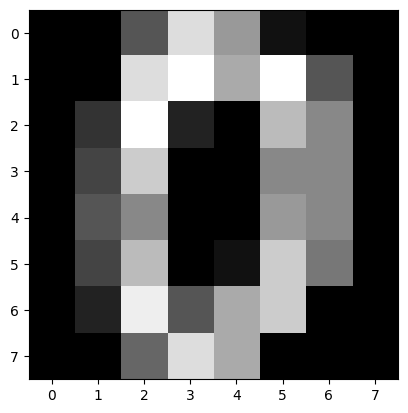

In [4]:
## showcase of data
plt.imshow(digits.images[0], cmap="gray")
plt.show()

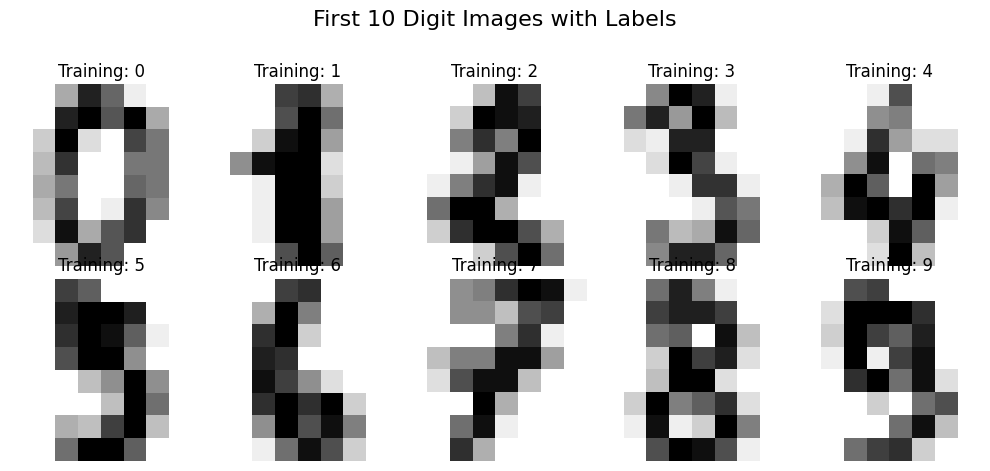

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))
for ax, image, label in zip(axes.flatten(), digits.images[:10], digits.target[:10]):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Training: {label}')
plt.suptitle('First 10 Digit Images with Labels', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [6]:
## checking the null values
import numpy as np
print(f"Number of NaN values in digits.data: {np.isnan(digits.data).sum()}")

Number of NaN values in digits.data: 0


In [7]:
## checking the duplicate values
print(f"Number of duplicate values in digits.data: {np.sum(np.sum(digits.data, axis=1) == 0)}")

Number of duplicate values in digits.data: 0


## Splitting the Data into Training and Testing Sets

In [8]:
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1437, 64)
Shape of X_test: (360, 64)
Shape of y_train: (1437,)
Shape of y_test: (360,)


## Preprocessing: Scaling the Data

In [9]:
print('Before normalisation')
print(X_train[0])
X_train=X_train/255.0
X_test=X_test/255.0
print('After normalisation')
print(X_train[0])

Before normalisation
[ 0.  0.  3. 14.  1.  0.  0.  0.  0.  0. 12. 12.  0.  0.  0.  0.  0.  3.
 16.  6.  0.  0.  0.  0.  0.  5. 16.  2.  0.  0.  0.  0.  0.  6. 16.  2.
  5.  2.  0.  0.  0.  4. 16.  2. 12. 15.  2.  0.  0.  1. 14. 13.  2. 13.
 11.  0.  0.  0.  3. 11. 16. 13.  4.  0.]
After normalisation
[0.         0.         0.01176471 0.05490196 0.00392157 0.
 0.         0.         0.         0.         0.04705882 0.04705882
 0.         0.         0.         0.         0.         0.01176471
 0.0627451  0.02352941 0.         0.         0.         0.
 0.         0.01960784 0.0627451  0.00784314 0.         0.
 0.         0.         0.         0.02352941 0.0627451  0.00784314
 0.01960784 0.00784314 0.         0.         0.         0.01568627
 0.0627451  0.00784314 0.04705882 0.05882353 0.00784314 0.
 0.         0.00392157 0.05490196 0.05098039 0.00784314 0.05098039
 0.04313725 0.         0.         0.         0.01176471 0.04313725
 0.0627451  0.05098039 0.01568627 0.        ]


In [10]:
## The dataset is already in a flattened format (samples, features).
# X_train has shape (1437, 64) and X_test has shape (360, 64), where each row is a flattened image.
# No further flattening is needed for X_train and X_test.
# y_train and y_test are 1D arrays of labels and do not need to be flattened.

In [11]:
## importing important libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.metrics import categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping
# Relu and softmax are activation functions, typically used within layers like Dense(units, activation='relu')
# or imported as from tensorflow.keras.activations import relu, softmax

In [12]:
model = Sequential()
model.add(Dense(units=128, activation='relu', input_shape=(64,))) # Input layer
model.add(Dropout(0.2))
model.add(Dense(units=64, activation='relu')) # Hidden layer 1
model.add(Dropout(0.2))
model.add(Dense(units=10, activation='softmax')) # Output layer for 10 classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
## Compile the model
# Convert y_train and y_test to one-hot encoded format for categorical_crossentropy
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=10)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=categorical_crossentropy,
    metrics=[categorical_accuracy]
)

In [15]:
## Train the model

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_test, y_test_one_hot),
    callbacks=[early_stopping]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.2728 - loss: 2.2693 - val_categorical_accuracy: 0.4028 - val_loss: 2.2207
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.4850 - loss: 2.1203 - val_categorical_accuracy: 0.4944 - val_loss: 1.9844
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.5762 - loss: 1.7810 - val_categorical_accuracy: 0.6056 - val_loss: 1.5473
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.6555 - loss: 1.3582 - val_categorical_accuracy: 0.8167 - val_loss: 1.1055
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.7439 - loss: 1.0348 - val_categorical_accuracy: 0.8556 - val_loss: 0.8200
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.7801 - loss: 0.8378 - val_categorical_accuracy: 0.8750 - val_loss: 0.6617
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.7989 - loss: 0.7252 - va

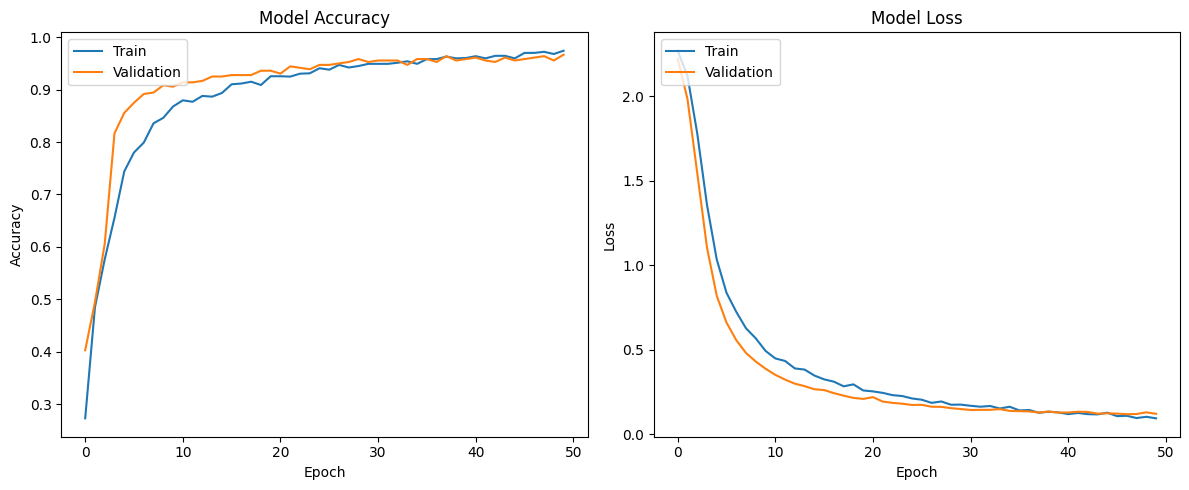

In [16]:
## Plotting the accuracy and loss curves
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

The plots show the training and validation accuracy and loss over the epochs. You can see that both the training and validation accuracy steadily increased, while both losses decreased, indicating that the model was learning effectively. The curves also show that the validation loss started to plateau, and in some cases slightly increase, which is where the early stopping mechanism would have kicked in to prevent further overfitting.

In [17]:
## Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Test Loss: 0.1198
Test Accuracy: 0.9611


In [18]:
X_test[0]

array([0.        , 0.        , 0.        , 0.02745098, 0.04705882,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.01568627, 0.0627451 , 0.03137255, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.04705882, 0.04313725,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.05882353, 0.03921569, 0.03137255, 0.02352941,
       0.00392157, 0.        , 0.        , 0.        , 0.05882353,
       0.0627451 , 0.03137255, 0.03921569, 0.03137255, 0.        ,
       0.        , 0.        , 0.05490196, 0.02745098, 0.        ,
       0.        , 0.04705882, 0.        , 0.        , 0.        ,
       0.03137255, 0.04313725, 0.        , 0.01960784, 0.0627451 ,
       0.00784314, 0.        , 0.        , 0.        , 0.03529412,
       0.05490196, 0.05490196, 0.01960784, 0.        ])

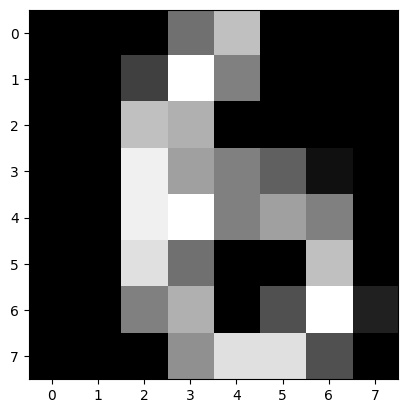

In [19]:
plt.imshow(X_test[0].reshape(8, 8), cmap="gray")
plt.show()

In [20]:
y_test[0]

np.int64(6)

In [21]:
X_test[15]

array([0.        , 0.        , 0.04313725, 0.0627451 , 0.03921569,
       0.        , 0.        , 0.        , 0.        , 0.02352941,
       0.05882353, 0.0627451 , 0.0627451 , 0.02352941, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00784314,
       0.04313725, 0.04705882, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.03529412, 0.03137255,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.01568627, 0.05882353, 0.00784314, 0.        , 0.        ,
       0.        , 0.00392157, 0.03529412, 0.05882353, 0.03529412,
       0.01176471, 0.        , 0.        , 0.        , 0.        ,
       0.0627451 , 0.0627451 , 0.0627451 , 0.0627451 , 0.02745098,
       0.        , 0.        , 0.        , 0.03921569, 0.05098039,
       0.03137255, 0.01568627, 0.00392157, 0.        ])

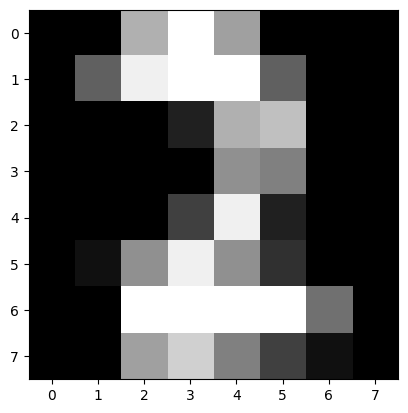

In [22]:
plt.imshow(X_test[15].reshape(8, 8), cmap="gray")
plt.show()

In [23]:
y_test[15]

np.int64(2)

### Conclusion and Strategies for Improvement

Your Artificial Neural Network for digit classification achieved a **Test Loss of 0.1198** and a **Test Accuracy of 0.9611** on the unseen test set, which is a strong performance for this dataset. The learning curves showed good convergence and generalization, with early stopping effectively preventing significant overfitting.